# Chapter 9 — Mathematical Notation for Programmers

> **Prerequisites:** ch001–ch008
>
> **You will learn:**
> - How to read mathematical notation without panic
> - The most common symbols and their computational equivalents
> - How to translate between math notation and Python code bidirectionally
> - Why notation choices matter: the same idea in bad notation is harder to work with
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Mathematical notation is a compression format. It encodes operations, quantifiers, and structures in dense symbolic form. Reading it fluently requires pattern recognition — the same skill as reading code in an unfamiliar language.

The barrier for programmers is usually notation, not ideas. The idea behind a summation $\sum_{k=1}^n f(k)$ is just a for-loop. The idea behind $\forall x \in S: P(x)$ is just `all(P(x) for x in S)`. Once you see the computational equivalent, the notation is no longer intimidating.

**This chapter builds a notation-to-code translation dictionary** for everything that appears in this book.

**Common misconception:** Mathematics would be clearer without all the symbols.

Wrong. The symbols exist because they compress repeated ideas into single characters. Without them, mathematical statements become paragraphs of English prose that are slower to read and harder to reason about. The notation is an optimization.

## 2. Intuition & Mental Models

**Physical analogy:** Musical notation. Sheet music is dense with symbols — clefs, time signatures, accidentals, dynamics. To a non-reader, it looks impenetrable. To a musician, it is a high-bandwidth instruction stream. Mathematical notation is exactly the same: a specialized compression format for people trained to read it.

**Computational analogy:** Regular expressions. `/^[A-Z][a-z]+$/` looks inscrutable to a beginner but expresses a pattern that would take 50 lines of explicit character-by-character checking. Fluency means seeing the compressed form directly, without translating to the explicit version first. Mathematical notation fluency works the same way.

Recall from ch002 *(Mathematics vs Programming Thinking)*: mathematical thinking is relational — it describes what is true rather than how to compute. The notation is built to express relational claims compactly.

## 3. Visualization

The visualization for this chapter is a reference table rendered as a matplotlib figure.

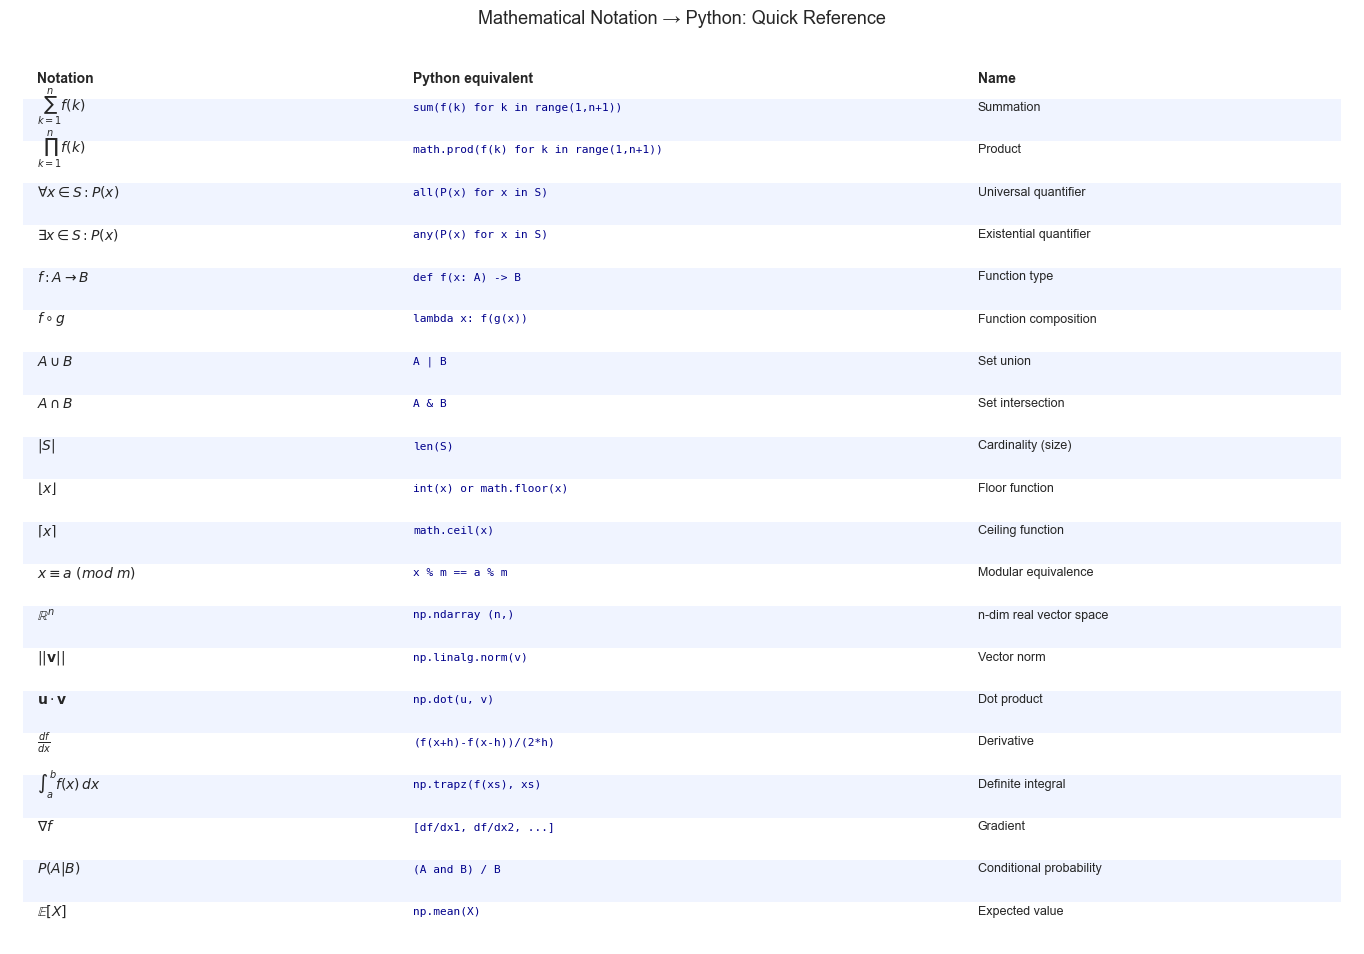

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

NOTATION = [
    (r'$\sum_{k=1}^{n} f(k)$',        'sum(f(k) for k in range(1,n+1))',         'Summation'),
    (r'$\prod_{k=1}^{n} f(k)$',       'math.prod(f(k) for k in range(1,n+1))',   'Product'),
    (r'$\forall x \in S: P(x)$',      'all(P(x) for x in S)',                    'Universal quantifier'),
    (r'$\exists x \in S: P(x)$',      'any(P(x) for x in S)',                    'Existential quantifier'),
    (r'$f: A \to B$',                 'def f(x: A) -> B',                        'Function type'),
    (r'$f \circ g$',                  'lambda x: f(g(x))',                       'Function composition'),
    (r'$A \cup B$',                   'A | B',                                   'Set union'),
    (r'$A \cap B$',                   'A & B',                                   'Set intersection'),
    (r'$|S|$',                        'len(S)',                                  'Cardinality (size)'),
    (r'$\lfloor x \rfloor$',          'int(x) or math.floor(x)',                 'Floor function'),
    (r'$\lceil x \rceil$',            'math.ceil(x)',                            'Ceiling function'),

    # ✅ FIXED HERE
    (r'$x \equiv a \ (mod\ m)$',      'x % m == a % m',                          'Modular equivalence'),

    (r'$\mathbb{R}^n$',               'np.ndarray (n,)',                         'n-dim real vector space'),
    (r'$||\mathbf{v}||$',             'np.linalg.norm(v)',                       'Vector norm'),
    (r'$\mathbf{u} \cdot \mathbf{v}$','np.dot(u, v)',                            'Dot product'),
    (r'$\frac{df}{dx}$',              '(f(x+h)-f(x-h))/(2*h)',                   'Derivative'),
    (r'$\int_a^b f(x)\,dx$',          'np.trapz(f(xs), xs)',                     'Definite integral'),
    (r'$\nabla f$',                   '[df/dx1, df/dx2, ...]',                   'Gradient'),
    (r'$P(A|B)$',                     '(A and B) / B',                           'Conditional probability'),
    (r'$\mathbb{E}[X]$',              'np.mean(X)',                              'Expected value'),
]

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

col_pos = [0.02, 0.3, 0.72]
row_height = 0.047

headers = ['Notation', 'Python equivalent', 'Name']
for header, xpos in zip(headers, col_pos):
    ax.text(xpos, 0.97, header,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            verticalalignment='top')

for i, (notation, code, name) in enumerate(NOTATION):
    y = 0.93 - i * row_height
    bg = '#f0f4ff' if i % 2 == 0 else 'white'

    rect = mpatches.FancyBboxPatch(
        (0.01, y - row_height * 0.8),
        0.98,
        row_height,
        boxstyle='square,pad=0',
        facecolor=bg,
        edgecolor='none',
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    ax.text(col_pos[0], y, notation,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='center')

    ax.text(col_pos[1], y, code,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='center',
            fontfamily='monospace',
            color='darkblue')

    ax.text(col_pos[2], y, name,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='center')

ax.set_title('Mathematical Notation → Python: Quick Reference',
             fontsize=13,
             pad=15)

plt.subplots_adjust(top=0.92, left=0.02, right=0.98, bottom=0.02)

plt.show()

## 4. Mathematical Formulation

The four most important notational patterns in this book:

**1. Summation and products:**
$$\sum_{k=1}^{n} k^2 = \frac{n(n+1)(2n+1)}{6}$$
The $\sum$ binds tighter than $+$ but looser than juxtaposition. The index variable $k$ is a *bound variable* — it does not exist outside the summation.

**2. Set-builder notation:**
$$\{x \in \mathbb{R} : x^2 < 4\} = (-2, 2)$$
The colon means "such that". In Python: `[x for x in candidates if x**2 < 4]`.

**3. Function application and composition:**
$$(f \circ g)(x) = f(g(x))$$
The small circle is composition. Note that $(f \circ g)$ applies $g$ first, then $f$ — right to left, opposite to the visual order.

**4. Big-O notation:**
$$f(n) = O(g(n)) \iff \exists C, n_0 : f(n) \leq C \cdot g(n) \text{ for all } n \geq n_0$$
This is the formal definition of the O-notation you use every time you discuss algorithmic complexity.

In [5]:
# --- Implementation: Notation translator ---
# Translates common mathematical expressions to runnable Python

import numpy as np

# Summation: sum_{k=1}^{n} f(k)
def sigma(f, start, end):
    """Mathematical summation ∑_{k=start}^{end} f(k)"""
    return sum(f(k) for k in range(start, end + 1))

# Product: prod_{k=1}^{n} f(k)
def pi_product(f, start, end):
    """Mathematical product ∏_{k=start}^{end} f(k)"""
    result = 1
    for k in range(start, end + 1):
        result *= f(k)
    return result

# Compose functions: (f ∘ g)(x) = f(g(x))
def compose(*fns):
    """Compose functions right-to-left: compose(f,g)(x) = f(g(x))"""
    def composed(x):
        result = x
        for fn in reversed(fns):
            result = fn(result)
        return result
    return composed

# Verify identities
print("Verification of mathematical identities:")
print()

for n in [5, 10, 20]:
    # Sum of squares identity: sum k^2 = n(n+1)(2n+1)/6
    lhs = sigma(lambda k: k**2, 1, n)
    rhs = n * (n+1) * (2*n+1) // 6
    print(f"  n={n}: Σk² = {lhs}, n(n+1)(2n+1)/6 = {rhs}, match={lhs==rhs}")

print()
print("Function composition:")
double = lambda x: 2 * x
add_one = lambda x: x + 1
square = lambda x: x ** 2

g = compose(double, add_one)  # double(add_one(x)) = 2(x+1)
print(f"  compose(double, add_one)(5) = {g(5)}  [expected: 2*(5+1)=12]")

h = compose(square, add_one, double)  # square(add_one(double(x))) = (2x+1)^2
print(f"  compose(sq, add1, dbl)(3) = {h(3)}  [expected: (2*3+1)^2=49]")

Verification of mathematical identities:

  n=5: Σk² = 55, n(n+1)(2n+1)/6 = 55, match=True
  n=10: Σk² = 385, n(n+1)(2n+1)/6 = 385, match=True
  n=20: Σk² = 2870, n(n+1)(2n+1)/6 = 2870, match=True

Function composition:
  compose(double, add_one)(5) = 12  [expected: 2*(5+1)=12]
  compose(sq, add1, dbl)(3) = 49  [expected: (2*3+1)^2=49]


## 5. Python Implementation
*(Incorporated above.)*

## 6. Experiments

In [6]:
# --- Experiment: Translation correctness ---
# Verify that our notation translators match standard library implementations
import numpy as np
import math

np.random.seed(42)

# Sigma vs np.sum
for _ in range(100):
    n = np.random.randint(1, 50)
    f = lambda k: k**2
    our_sum = sigma(f, 1, n)
    np_sum  = sum(k**2 for k in range(1, n+1))
    assert our_sum == np_sum, f"Mismatch at n={n}"
print("sigma() matches sum(): PASS (100 random tests)")

# Pi_product vs math.factorial
for n in range(1, 20):
    our_fact = pi_product(lambda k: k, 1, n)
    true_fact = math.factorial(n)
    assert our_fact == true_fact, f"Mismatch at n={n}"
print("pi_product(id, 1, n) = n!: PASS (n=1..19)")

# Composition
f = lambda x: x**2
g = lambda x: x + 3
assert compose(f, g)(5) == f(g(5)) == 64
assert compose(g, f)(5) == g(f(5)) == 28
print("compose(f,g)(x) == f(g(x)): PASS")

sigma() matches sum(): PASS (100 random tests)
pi_product(id, 1, n) = n!: PASS (n=1..19)
compose(f,g)(x) == f(g(x)): PASS


## 7. Exercises

**Easy 1.** Translate to Python: $\prod_{k=1}^{10}(1 + 1/k)$. Compute it and compare to the closed form $\frac{11!}{10!} = 11$. Wait — is that right? Compute both and check. *(Expected: the product equals 11; verify why)*

**Easy 2.** The set $\{n \in \mathbb{Z} : n^2 \leq 100\}$ contains exactly which integers? Write a Python set comprehension that computes it. *(Expected: integers from -10 to 10)*

**Medium 1.** Write a function `big_O_verify(f, g, n_vals)` that empirically tests whether `f(n) = O(g(n))` by checking if the ratio `f(n)/g(n)` remains bounded as n grows. Test it on: (a) f=n², g=n³ (should be O); (b) f=n³, g=n² (should NOT be O); (c) f=n·log(n), g=n² (should be O).

**Medium 2.** The composition `f ∘ g ≠ g ∘ f` in general. Find three pairs of functions (f,g) where composition is commutative and three where it is not. State a conjecture about when `f ∘ g = g ∘ f`.

**Hard.** Einstein summation notation $C_{ij} = \sum_k A_{ik} B_{kj}$ is matrix multiplication. Implement `einsum(subscripts, *arrays)` from scratch (for the cases `ij,jk->ik` and `ij,ij->` only) without using `np.einsum`, then verify your output against `np.einsum`. *(Challenge: also implement `i,i->` for dot product and `ij->ji` for transpose)*

## 8. Mini Project

**Notation Decoder Ring**: Given a list of mathematical expressions as LaTeX strings, parse the structure (summation / product / set comprehension / quantifier) and generate the equivalent Python code. This is a mini compiler from mathematical notation to Python.

In [7]:
# --- Mini Project: Notation pattern recognizer ---
# Recognizes common notation patterns and generates Python equivalents.
# Not a full parser — a pattern-matching system for the 20 most common forms.

import re

NOTATION_PATTERNS = [
    (r'sum.*k=([0-9]+).*n.*k\^2',
     lambda m: f'sum(k**2 for k in range({m.group(1)}, n+1))'),
    (r'prod.*k=([0-9]+).*n.*k',
     lambda m: f'math.prod(range({m.group(1)}, n+1))'),
    (r'forall.*in.*:',
     lambda m: 'all(P(x) for x in S)'),
    (r'exists.*in.*:',
     lambda m: 'any(P(x) for x in S)'),
]

def translate_notation(description):
    """
    Attempt to translate a natural-language description of notation to Python.
    Returns best guess or 'translation not available'.
    """
    desc = description.lower()
    for pattern, generator in NOTATION_PATTERNS:
        m = re.search(pattern, desc)
        if m:
            try:
                return generator(m)
            except:
                pass
    return 'translation not available — implement manually'

# Test it
queries = [
    'sum from k=1 to n of k^2',
    'product from k=1 to n of k',
    'forall x in S: P(x) holds',
    'exists y in T: y > 0',
    'derivative of f at x',  # not in patterns
]

for q in queries:
    print(f"Input:  {q}")
    print(f"Output: {translate_notation(q)}")
    print()

Input:  sum from k=1 to n of k^2
Output: sum(k**2 for k in range(1, n+1))

Input:  product from k=1 to n of k
Output: math.prod(range(1, n+1))

Input:  forall x in S: P(x) holds
Output: all(P(x) for x in S)

Input:  exists y in T: y > 0
Output: any(P(x) for x in S)

Input:  derivative of f at x
Output: translation not available — implement manually



## 9. Chapter Summary & Connections

- Mathematical notation is a compression format; fluency means reading compressed form directly, not translating mentally each time
- Every summation is a for-loop, every quantifier is `all`/`any`, every set-builder is a list comprehension — the computational equivalents are always present
- Composition is right-to-left; Big-O is a formal claim with a specific mathematical definition, not just informal shorthand
- The notation translator built here is the foundation for reading all subsequent chapters fluently

**Forward:** This chapter's notation is used in every subsequent chapter. The summation notation becomes central in ch154 — Matrix Multiplication. Set notation is needed for ch241 — Sample Spaces. Gradient notation ($\nabla f$) is the core of Part VII — Calculus.

**Backward:** ch002 *(Mathematics vs Programming Thinking)* established that relational thinking describes *what is true*. Mathematical notation is the language in which those relational descriptions are written. This chapter is the dictionary.